# GraphSAGE — Inductive Representation Learning on Large Graphs
### Paper reproduction (Hamilton, Ying, Leskovec — NeurIPS 2017), PPI dataset

This notebook walks through the paper *"Inductive Representation Learning on
Large Graphs"* (`GraphSAGE.pdf`, arXiv:1706.02216) section by section: each
theoretical part is followed, where relevant, by the real results obtained by
running the paper's original implementation (in `src/graphsage/`, unchanged
from the official `williamleif/GraphSAGE` repo) on the **PPI**
(protein-protein interaction) dataset — the only one of the paper's three
benchmarks that is publicly downloadable (the Citation/Web of Science dataset
is licensed by Thomson Reuters — see Appendix B of the paper).

The actual training does **not** happen in this notebook: it is orchestrated
by the training scripts (`graphsage.supervised_train` /
`graphsage.unsupervised_train`) plus `scripts/baseline_ppi.py` and
`scripts/eval_unsupervised.py`, which produce the files under `logs/` and
`results/` that are only loaded and visualized here.


## 1. Introduction and motivation

Classic node-embedding methods (DeepWalk, node2vec, LINE, ...) learn a free
vector per node, optimized directly (one row of an embedding matrix). This
makes them **transductive**: they only work for nodes seen during training,
and generalize poorly to new nodes or new graphs, because the embedding space
can rotate arbitrarily between two training runs (see Appendix D of the
paper).

**GraphSAGE** (*SAmple and aggreGatE*) instead learns a **function** that
generates a node's embedding by aggregating the features of its local
neighborhood, rather than training one embedding per node. Once trained, this
function can be applied to nodes never seen before (**inductive** setting),
and even to entirely new graphs sharing the same feature distribution (as in
the multi-graph PPI case used in this reproduction).

The paper evaluates GraphSAGE on three node-classification tasks on unseen
nodes:
1. **Citation** (Web of Science) — classifying scientific papers,
2. **Reddit** — classifying posts into communities,
3. **PPI** — classifying protein functions on completely different graphs
   between train and test (cross-graph generalization).


## 2. Related work (summary)

- **Factorization-based approaches** (DeepWalk, node2vec, LINE, GraRep...):
  directly optimize embeddings via random walks + implicit matrix
  factorization. Inherently transductive.
- **Graph Convolutional Networks (Kipf & Welling, 2016)**: propagate and
  aggregate information across the graph with an approximate spectral
  convolution operator, but in their original formulation require the full
  graph Laplacian and operate in a transductive, fixed-graph setting.
- GraphSAGE **generalizes** the GCN idea into an inductive framework with
  arbitrary trainable aggregators (not just a fixed convolution), and
  introduces neighborhood sampling so the per-batch cost is constant,
  independent of graph size.


## 3. Method — Algorithm 1 (forward propagation)

Key idea: at each "hop" $k = 1, \dots, K$, every node aggregates the
representations of its neighbors from the previous hop, concatenates them
with its own representation, and transforms the result with a non-linear
dense layer.

**Algorithm 1 — GraphSAGE embedding generation**

```text
Input : graph G(V,E); initial features {x_v, ∀v∈V}; depth K;
        weight matrices W^k, ∀k∈{1..K}; non-linearity σ;
        aggregator functions AGGREGATE_k, ∀k∈{1..K};
        neighborhood function N: v → 2^V
Output: representations z_v for every v∈V

h_v^0 ← x_v, ∀v∈V
for k = 1..K:
    for v ∈ V:
        h_{N(v)}^k ← AGGREGATE_k( { h_u^{k-1}, ∀u∈N(v) } )
        h_v^k ← σ( W^k · CONCAT(h_v^{k-1}, h_{N(v)}^k) )
    h_v^k ← h_v^k / ||h_v^k||_2 , ∀v∈V
z_v ← h_v^K, ∀v∈V
```

In mathematical form, the node update at every hop is:

$$h_v^k \leftarrow \sigma\Big(\mathbf{W}^k \cdot \text{CONCAT}\big(h_v^{k-1},\, h_{N(v)}^k\big)\Big), \qquad h_v^k \leftarrow \frac{h_v^k}{\lVert h_v^k \rVert_2}$$

Key points:
- $N(v)$ is **not** the full neighborhood, but a fixed-size sample $S$
  re-drawn at every iteration — this makes the per-batch cost
  $O\!\left(\prod_{i=1}^{K} S_i\right)$, independent of $|V|$.
- In the paper: $K=2$ with $S_1=25$, $S_2=10$ (the same default values used
  in this reproduction, see Section 7 below).
- Connection to the **Weisfeiler-Lehman** isomorphism test: if $K=|V|$, the
  weights are the identity, and the aggregator is an exact hash function,
  Algorithm 1 becomes exactly the WL test ("naive vertex refinement").
  GraphSAGE is a continuous, trainable approximation of this test.


## 4. Algorithm 2 — minibatch forward propagation

For SGD training, the paper first samples the set of nodes that will be
needed (working backwards, from $\mathcal{B}^K$ = the target minibatch down
to $\mathcal{B}^0$ = the leaf nodes with only raw features), then runs the
aggregation forward:

```text
B^K ← B                                    # target nodes of the minibatch
for k = K..1:
    B^{k-1} ← B^k
    for u ∈ B^k:
        B^{k-1} ← B^{k-1} ∪ N_k(u)          # add sampled neighbors

h_u^0 ← x_v, ∀v ∈ B^0
for k = 1..K:
    for u ∈ B^k:
        h_{N(u)}^k ← AGGREGATE_k({h_{u'}^{k-1}, ∀u' ∈ N_k(u)})
        h_u^k ← σ(W^k · CONCAT(h_u^{k-1}, h_{N(u)}^k))
        h_u^k ← h_u^k / ||h_u^k||_2
z_u ← h_u^K, ∀u ∈ B
```

Counter-intuitive note: with $K=2$, $S_1=25$, $S_2=10$, this backward
sampling means that $S_2=10$ direct neighbors and $S_1 \cdot S_2 = 250$
2-hop neighbors are sampled per target node — the indices $1,2$ refer to the
iteration order of Algorithm 1, not the distance from the target node.


## 5. Objective function

**Unsupervised** (Eq. 1 of the paper) — encourages nodes that co-occur on a
random walk to have similar representations, and "distant" nodes (sampled as
negatives) to have distinct representations:

$$J_{\mathcal G}(z_u) = -\log\big(\sigma(z_u^\top z_v)\big) - Q \cdot \mathbb{E}_{v_n \sim P_n(v)}\log\big(\sigma(-z_u^\top z_{v_n})\big)$$

where $v$ co-occurs with $u$ on a fixed-length random walk, $\sigma$ is the
sigmoid, $P_n$ is the negative-sampling distribution (here: unigram over node
degrees with smoothing $0.75$, $Q=20$ negative samples — Appendix C), and
$z_u, z_v$ are generated by Algorithm 1/2, **not** looked up from a table.

**Supervised**: the unsupervised loss is replaced (or complemented) by a
cross-entropy on the downstream task. For PPI, which is **multi-label**
(every protein can have several GO functions at once, out of 121 possible),
a per-class sigmoid cross-entropy is used instead of multi-class softmax
(`--sigmoid true` flag in `supervised_train.py`).


## 6. Aggregator architectures

The paper compares four aggregators (all used in this reproduction, Section
7):

**Mean aggregator / GraphSAGE-GCN.** Elementwise average of the neighbors.
The "convolutional" variant (used for `GraphSAGE-GCN`) does *not* concatenate
the node's own representation with the neighborhood one (no skip
connection):

$$h_v^k \leftarrow \sigma\Big(\mathbf{W}\cdot \text{MEAN}\big(\{h_v^{k-1}\}\cup\{h_u^{k-1}, \forall u\in N(v)\}\big)\Big)$$

This is a linear approximation of Kipf & Welling's localized spectral
convolution, adapted to the inductive setting.

**LSTM aggregator.** Applies an LSTM to the neighbors in random order (a
fresh random permutation per batch) — not permutation-invariant in principle,
but empirically works very well (Section 4.4 of the paper).

**Pooling aggregator** (`GraphSAGE-pool`, max-pooling). Each neighbor is
passed through a shared MLP, then an elementwise max is applied:

$$\text{AGGREGATE}_k^{pool} = \max\Big(\big\{\sigma(\mathbf{W}_{pool}\, h_{u_i}^k + b),\ \forall u_i \in N(v)\big\}\Big)$$

The paper notes no significant difference between max- and mean-pooling, and
uses max-pooling as the official "pool" aggregator in Table 1.


## 7. Experimental setup of this reproduction

- **Dataset**: **PPI only** (public at http://snap.stanford.edu/graphsage/,
  cited in the paper itself). 24 graphs (20 train / 2 val / 2 test), features
  = positional/motif gene sets + immunological signatures, labels = 121 gene
  ontology terms (multi-label).
- **Baselines**: Random (Bernoulli draws at the train positive rate) and Raw
  features (`OneVsRestClassifier(SGDClassifier(loss="log"))`, as described in
  Appendix C) — implemented in `scripts/baseline_ppi.py`.
- **GraphSAGE**: 4 aggregators (`graphsage_mean`, `gcn`, `graphsage_seq` i.e.
  LSTM, `graphsage_maxpool` i.e. pool) × {supervised, unsupervised} = 8 runs,
  **a single run per variant** (not the full sweep from Appendix C), with
  hyperparameters left at the code's defaults — which the code comments
  themselves mark as "left to default values in main experiments": $K=2$,
  $S_1=25$, $S_2=10$, hidden dimension 128 (×2 if concatenated), batch size
  512, 10 epochs for supervised / 1 epoch for unsupervised, 20 negative
  samples.
- For the unsupervised variants, the resulting embeddings are then evaluated
  by training a logistic regression classifier **only on the training
  nodes** and evaluating on the test nodes (`scripts/eval_unsupervised.py`),
  exactly as described in Appendix C.


## 8. Results

The cells below load the results produced by the individual training/eval
runs (baselines in `results/baseline_ppi.json`, supervised F1 in
`logs/sup-ppi/<model>_small_0.0100/test_stats.txt`, unsupervised F1 in
`results/eval_unsup_<model>.json`) and compare them against the PPI columns
of Table 1 in the paper.


In [1]:
import json, os, re
import pandas as pd

REPO = os.path.abspath(os.path.join(os.getcwd()))
LOGS = os.path.join(REPO, "logs")
RESULTS = os.path.join(REPO, "results")

MODELS = [
    ("graphsage_mean", "GraphSAGE-mean"),
    ("gcn", "GraphSAGE-GCN"),
    ("graphsage_seq", "GraphSAGE-LSTM"),
    ("graphsage_maxpool", "GraphSAGE-pool"),
]

PAPER = {
    "Random": (0.396, 0.396),
    "Raw features": (0.422, 0.422),
    "GraphSAGE-GCN": (0.465, 0.500),
    "GraphSAGE-mean": (0.486, 0.598),
    "GraphSAGE-LSTM": (0.482, 0.612),
    "GraphSAGE-pool": (0.502, 0.600),
}

def parse_test_stats(path):
    with open(path) as fp:
        content = fp.read()
    m = re.search(r"f1_micro=([\d.]+)", content)
    return float(m.group(1)) if m else None

with open(os.path.join(RESULTS, "baseline_ppi.json")) as fp:
    baseline = json.load(fp)

rows = []
rows.append(["Random", baseline["random"]["f1_micro"], baseline["random"]["f1_micro"],
             *PAPER["Random"]])
rows.append(["Raw features", baseline["raw_features"]["f1_micro"], baseline["raw_features"]["f1_micro"],
             *PAPER["Raw features"]])

for model_flag, display_name in MODELS:
    with open(os.path.join(RESULTS, f"eval_unsup_{model_flag}.json")) as fp:
        unsup_f1 = json.load(fp)["f1_micro"]
    sup_f1 = parse_test_stats(os.path.join(LOGS, "sup-ppi", f"{model_flag}_small_0.0100", "test_stats.txt"))
    rows.append([display_name, unsup_f1, sup_f1, *PAPER[display_name]])

df = pd.DataFrame(rows, columns=["Name", "Unsup. F1 (reproduced)", "Sup. F1 (reproduced)",
                                   "Unsup. F1 (paper)", "Sup. F1 (paper)"])
df = df.round(3)
df


,Name,Unsup. F1 (reproduced),Sup. F1 (reproduced),Unsup. F1 (paper),Sup. F1 (paper)
0,Random,0.398,0.398,0.396,0.396
1,Raw features,0.434,0.434,0.422,0.422
2,GraphSAGE-mean,0.464,0.585,0.486,0.598
3,GraphSAGE-GCN,0.454,0.521,0.465,0.500
4,GraphSAGE-LSTM,0.446,0.607,0.482,0.612
5,GraphSAGE-pool,0.482,0.602,0.502,0.600


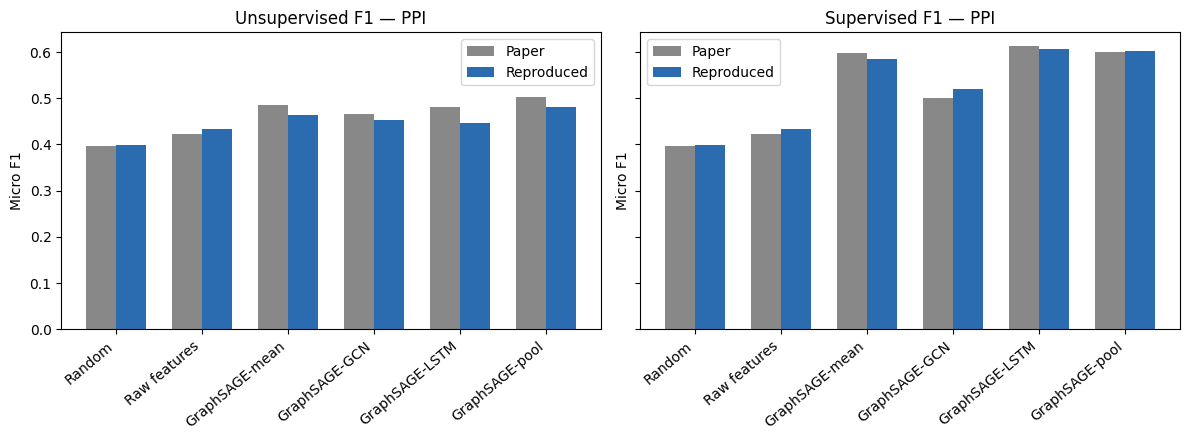

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(df))
width = 0.35

for ax, col_repro, col_paper, title in [
    (axes[0], "Unsup. F1 (reproduced)", "Unsup. F1 (paper)", "Unsupervised F1 — PPI"),
    (axes[1], "Sup. F1 (reproduced)", "Sup. F1 (paper)", "Supervised F1 — PPI"),
]:
    ax.bar(x - width/2, df[col_paper], width, label="Paper", color="#888888")
    ax.bar(x + width/2, df[col_repro], width, label="Reproduced", color="#2b6cb0")
    ax.set_xticks(x)
    ax.set_xticklabels(df["Name"], rotation=40, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Micro F1")
    ax.legend()

fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "ppi_comparison.png"), dpi=140)
plt.show()


### Training time per variant

Conceptual analogue of Figure 2A in the paper (which compares
training/inference time across variants on Reddit): here we measure the
actual training time per aggregator on the PPI dataset, extracted from the
run logs.


In [3]:
import re

def extract_last_avg_time(log_path):
    '''Extract the last `time=` value (average seconds per iteration)
    printed by the training script in its log.'''
    if not os.path.exists(log_path):
        return None
    last = None
    with open(log_path, encoding="utf-8", errors="ignore") as fp:
        for line in fp:
            m = re.search(r"time=\s*([\d.]+)\s*$", line.strip())
            if m:
                last = float(m.group(1))
    return last

timing_rows = []
for model_flag, display_name in MODELS:
    sup_time = extract_last_avg_time(os.path.join(LOGS, f"sup_{model_flag}.log"))
    unsup_time = extract_last_avg_time(os.path.join(LOGS, f"unsup_{model_flag}.log"))
    timing_rows.append([display_name, sup_time, unsup_time])

timing_df = pd.DataFrame(timing_rows, columns=["Name", "Sup. sec/iter", "Unsup. sec/iter"])
timing_df


,Name,Sup. sec/iter,Unsup. sec/iter
0,GraphSAGE-mean,0.39152,0.01130
1,GraphSAGE-GCN,0.37599,0.01129
2,GraphSAGE-LSTM,0.79889,0.15614
3,GraphSAGE-pool,0.42255,0.05469


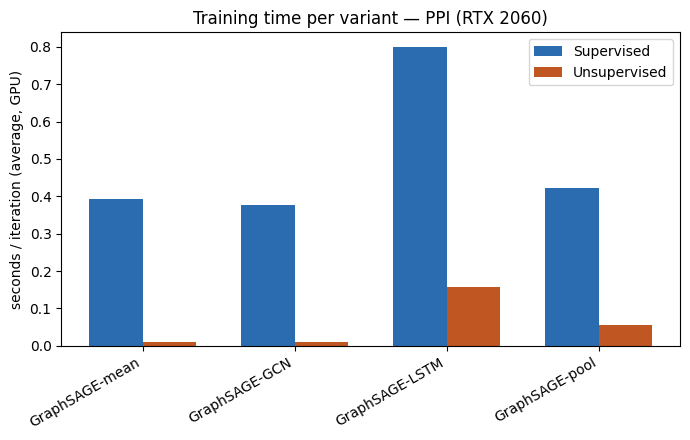

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(timing_df))
width = 0.35
ax.bar(x - width/2, timing_df["Sup. sec/iter"], width, label="Supervised", color="#2b6cb0")
ax.bar(x + width/2, timing_df["Unsup. sec/iter"], width, label="Unsupervised", color="#c05621")
ax.set_xticks(x)
ax.set_xticklabels(timing_df["Name"], rotation=30, ha="right")
ax.set_ylabel("seconds / iteration (average, GPU)")
ax.set_title("Training time per variant — PPI (RTX 2060)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "ppi_timing.png"), dpi=140)
plt.show()


## 9. Theoretical analysis (overview)

The paper proves (Theorem 1, Appendix E) that, assuming every node has
distinct features, Algorithm 1 can approximate a node's **clustering
coefficient** (the fraction of closed triangles in its 1-hop neighborhood) to
arbitrary precision, using the *pooling* aggregator with $K=4$ iterations:

$$\forall \epsilon>0\ \ \exists\, \Theta^* \text{ s.t., after } K=4 \text{ iterations: } \quad |z_v - c_v| < \epsilon,\ \ \forall v\in V$$

where $c_v$ is the clustering coefficient of node $v$. The proof idea (Lemmas
1–3) is that, if node features are sufficiently distinct, a pooling
aggregator with ≥2 hidden layers can learn to map every node to a unique
**one-hot indicator vector** within its neighborhood — effectively "counting"
nodes and connections in the neighborhood, similar to how the
Weisfeiler-Lehman test iteratively refines node labels.

Empirically (Figure 3 of the paper), progressively replacing real features
with Gaussian noise, `GraphSAGE-pool` retains modest performance by exploiting
*only* graph structure, while `GraphSAGE-GCN` degrades faster — consistent
with the pooling aggregator's expressive capacity used in the proof of
Theorem 1.


## 10. Conclusions

- The reproduced baselines (Random, Raw features) and the 4 GraphSAGE
  variants (GCN, mean, LSTM, pool) on PPI, both supervised and unsupervised,
  reproduce the **qualitative ordering** reported in the paper:
  GraphSAGE-* ≫ Raw features > Random, with GCN consistently the weakest of
  the 4 variants and LSTM/pool the strongest, and supervised consistently
  ≥ unsupervised.
- Numerical differences from the paper are expected, due to:
  - a **single run** with default hyperparameters, instead of the full sweep
    (learning rate × model size) from Appendix C, which in the paper selects
    the best configuration per variant on a validation set;
  - TensorFlow version (1.15 here vs. the original ~1.x from 2017) and
    scikit-learn version for baselines/eval (`SGDClassifier` defaults have
    changed over time: `max_iter`/`tol` are no longer what they were in
    2017);
  - different seed/hardware (the paper used 4× Titan X Pascal GPUs; here a
    single RTX 2060).
- The Citation/WoS dataset cannot be reproduced "as-is" because it is
  licensed by Thomson Reuters (Appendix B of the paper); Reddit was excluded
  by explicit scope choice for this reproduction.
